<a href="https://colab.research.google.com/github/Dragan-Al/ml-product-reviews-project/blob/main/notebooks/product_reviews_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading and inspecting Dataset

In [3]:
import pandas as pd

# load dataset from GitHub

url = "https://raw.githubusercontent.com/Dragan-Al/ml-product-reviews-project/main/data/product_reviews_full.csv"
df = pd.read_csv(url)

# Print Shape (number of rows and columns)
print("Dataset shape (rows, columns):", df.shape)

# Show first 5 rows

print("\nFirst 5 rows")
display(df.head())

# Show column data types and non-null counts
print("\nDataset info:")
df.info()



Dataset shape (rows, columns): (171380, 6)

First 5 rows


,review_uuid,product_name,product_price,review_title,review_text,sentiment
0,31b07b9a-4567-4db1-81f6-1bcef33b3e7b,Candes 12 L Room/Personal Air Cooler??????(Whi...,48.18,Super!,great cooler excellent air flow and for this p...,positive
1,1cb2b4b5-9805-4c2d-9393-6b1382cb7c53,Candes 12 L Room/Personal Air Cooler??????(Whi...,48.18,Awesome,best budget 2 fit cooler nice cooling,positive
2,f64165f0-29a2-4cfb-8b15-13c0c893e54d,Candes 12 L Room/Personal Air Cooler??????(Whi...,48.18,Fair,the quality is good but the power of air is de...,positive
3,e442e083-a343-4052-b015-41e531e52d3e,Candes 12 L Room/Personal Air Cooler??????(Whi...,48.18,Useless product,very bad product its a only a fan,negative
4,f4abefb8-22f0-4672-af73-2aa2954b24e0,Candes 12 L Room/Personal Air Cooler??????(Whi...,48.18,Fair,ok ok product,Neutral



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171380 entries, 0 to 171379
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   review_uuid    171380 non-null  object
 1   product_name   171380 non-null  object
 2   product_price  170954 non-null  object
 3   review_title   171379 non-null  object
 4   review_text    171379 non-null  object
 5   sentiment      166369 non-null  object
dtypes: object(6)
memory usage: 7.8+ MB


## Count missing values per column


In [4]:
print("Missing calues per Column:")
print(df.isna().sum())

Missing calues per Column:
review_uuid         0
product_name        0
product_price     426
review_title        1
review_text         1
sentiment        5011
dtype: int64


## Visualize missing data with seaborn heatmap

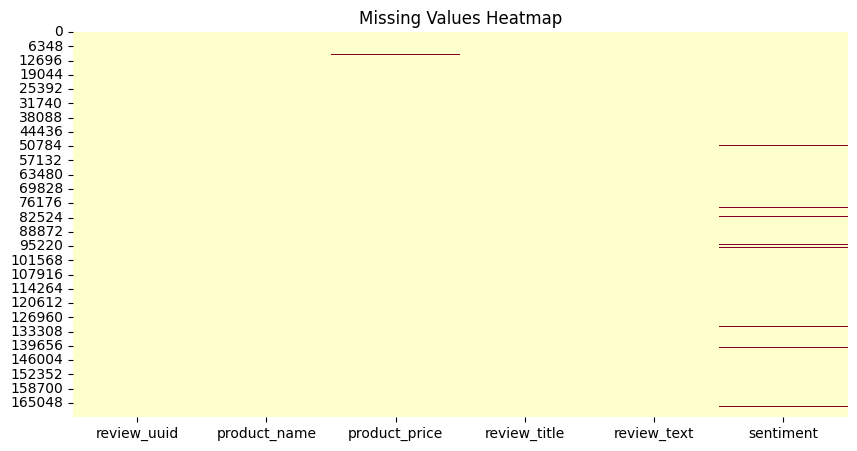

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.show()

## Count occurances od each sentiment label


In [11]:
sentiment_counts = df["sentiment"].value_counts()

#print counts

print("Sentiment distribution (counts):")
print(sentiment_counts)

Sentiment distribution (counts):
sentiment
positive    85537
negative    32369
Positive    22361
Negative    12392
neutral     10508
Neutral      3202
Name: count, dtype: int64


## Plot sentiment Distribution

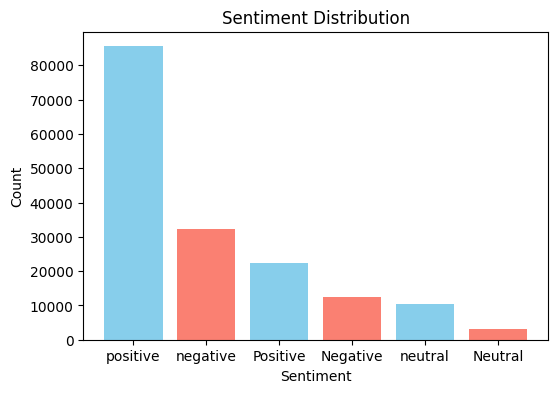

In [12]:
plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=["skyblue", "salmon"])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.show()

# Check the 'Product price' column

In [15]:
print("Data type of product_price column:", df["product_price"].dtype)

print("\nFirst 10 values in product_price column")
print(df["product_price"].head(10))

print("\nTop 20 most frequent values in product_price column:")
print(df["product_price"].value_counts().head(20))

problematic_values = ["Free", "Not Availible", "N/A", "None", "-", "free", "Unvailable"]
mask_problematic = df["product_price"].astype(str).str.strip().isin(problematic_values)
df_problematic = df[mask_problematic]

print(f"\nFound {len(df_problematic)} rows with problematic values:")
display(df_problematic[["product_price"]].drop_duplicates())

price_clean = df["product_price"].astype(str).str.strip()
price_numeric = pd.to_numeric(price_clean, errors = "coerce")

invalid_prices = df[price_numeric.isna()]
print("Number of non-numeric prices:", len(invalid_prices))
display(invalid_prices[["product_price"]].drop_duplicates().head(20))


Data type of product_price column: object

First 10 values in product_price column
0    48.18
1    48.18
2    48.18
3    48.18
4    48.18
5    48.18
6    48.18
7    48.18
8    48.18
9    48.18
Name: product_price, dtype: object

Top 20 most frequent values in product_price column:
product_price
2.63        4483
5.41        2648
$5.41       2577
19.27       2575
$2.63       2499
42.16       2242
168.66      2175
8.42        2103
6.01        1857
373.48      1824
3.6         1778
18.06       1710
$19.27      1671
$3.60       1608
96.37       1496
$168.66     1461
3.0         1395
$6.01       1359
3.24        1333
2.4         1321
Name: count, dtype: int64

Found 0 rows with problematic values:


,product_price


Number of non-numeric prices: 68858


,product_price
22,NaN
34279,$6.86
34512,$2.76
34553,$6.95
35245,$4.35
36212,$19.27
36613,$21.67
36622,$7.22
36753,$9.63
36766,$7.82


## Drop all rows with missing values


In [16]:
df = df.dropna()

print("New dataset shape:", df.shape)

print("Missing values per column:")
print(df.isna().sum())

New dataset shape: (165960, 6)
Missing values per column:
review_uuid      0
product_name     0
product_price    0
review_title     0
review_text      0
sentiment        0
dtype: int64
